# DO Card Classifier Training

Train a simple full-card classifier using the data produced by the DO notebooks: reference card crops, augmented card crops, and labeled crops from augmented scenes. The notebook saves a single classifier that predicts labels such as `r_5`, `wild`, or `draw_4` directly.

In [1]:
from __future__ import annotations

import csv
import json
import random
from collections import Counter
from dataclasses import dataclass
from pathlib import Path

import cv2
import joblib
import matplotlib.pyplot as plt
import numpy as np
from skimage.feature import hog as skimage_hog
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

PROJECT_ROOT = Path.cwd().resolve()
while not ((PROJECT_ROOT / "project" / "training_data").exists() and (PROJECT_ROOT / "data").exists()):
    if PROJECT_ROOT.parent == PROJECT_ROOT:
        raise FileNotFoundError("Could not locate workspace root containing project/training_data and data/.")
    PROJECT_ROOT = PROJECT_ROOT.parent

PROJECT_DIR = PROJECT_ROOT / "project"
TRAINING_DATA = PROJECT_DIR / "training_data"
MODELS_DIR = PROJECT_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

REFERENCE_CSV = TRAINING_DATA / "object_labels" / "reference_cards" / "reference_do.csv"
AUG_CSV = TRAINING_DATA / "object_labels" / "augmented_cards" / "aug.csv"
SCENE_LABELS_PATH = TRAINING_DATA / "object_labels" / "augmented_scenes" / "labels.json"

REF_CARDS_DIR = TRAINING_DATA / "training_images" / "reference_cards"
AUG_CARDS_DIR = TRAINING_DATA / "training_images" / "augmented_cards"
SCENE_IMAGES_DIR = TRAINING_DATA / "training_images" / "augmented_scenes"

CARD_CLF_PATH = MODELS_DIR / "card_clf_do.pkl"
CARD_CLASSES_PATH = MODELS_DIR / "card_classes_do.npy"
CARD_CONFIG_PATH = MODELS_DIR / "card_classifier_do_config.json"

for required_path in (REFERENCE_CSV, REF_CARDS_DIR):
    if not required_path.exists():
        raise FileNotFoundError(f"Missing required classifier input: {required_path}")

print(f"Project root: {PROJECT_ROOT}")
print(f"Reference labels: {REFERENCE_CSV}")
print(f"Augmented labels: {AUG_CSV}")
print(f"Scene labels:     {SCENE_LABELS_PATH}")
print(f"Model output:     {CARD_CLF_PATH}")

Project root: C:\Users\doria\Documents\EPFL\IA\iapr2026do
Reference labels: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\object_labels\reference_cards\reference_do.csv
Augmented labels: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\object_labels\augmented_cards\aug.csv
Scene labels:     C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\training_data\object_labels\augmented_scenes\labels.json
Model output:     C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\card_clf_do.pkl


## Helper Functions

The classifier keeps the same simple pipeline but now combines global descriptors with extra center-symbol shape descriptors and lightweight scene-bbox sanity filtering.

In [2]:
IMG_SIZE = 128
FOURIER_COEFFS = 32
CENTER_CROP_FRACTION = 0.62
MIN_SCENE_BOX_SIDE = 28
MAX_SCENE_BOX_ASPECT = 4.5
SOURCE_WEIGHTS = {"reference": 1.15, "augmented_card": 1.0, "augmented_scene": 0.75}


@dataclass(frozen=True)
class CardSample:
    source: str
    label: str
    image_path: Path
    bbox: tuple[int, int, int, int] | None = None


def clean_label(label: str) -> str:
    return str(label).strip()


def resolve_project_path(path_value: str | Path) -> Path:
    path = Path(path_value)
    return path if path.is_absolute() else PROJECT_ROOT / path


def reference_crop_path(image_id: str) -> Path:
    tag, separator, crop_index = image_id.rpartition("_crop_")
    if separator == "":
        raise ValueError(f"Unexpected reference image_id: {image_id}")
    return REF_CARDS_DIR / tag / "crops" / f"crop_{crop_index}.jpg"


def is_reasonable_scene_bbox(bbox: tuple[int, int, int, int]) -> bool:
    x0, y0, x1, y1 = map(int, bbox)
    bw = x1 - x0
    bh = y1 - y0
    if bw < MIN_SCENE_BOX_SIDE or bh < MIN_SCENE_BOX_SIDE:
        return False
    aspect = max(bw / max(1, bh), bh / max(1, bw))
    return aspect <= MAX_SCENE_BOX_ASPECT


def crop_with_margin(img_bgr: np.ndarray, bbox: tuple[int, int, int, int], margin_fraction: float = 0.08) -> np.ndarray:
    x0, y0, x1, y1 = map(int, bbox)
    h, w = img_bgr.shape[:2]
    bw = max(1, x1 - x0)
    bh = max(1, y1 - y0)
    margin = int(round(margin_fraction * max(bw, bh)))
    x0 = max(0, x0 - margin)
    y0 = max(0, y0 - margin)
    x1 = min(w, x1 + margin)
    y1 = min(h, y1 + margin)
    return img_bgr[y0:y1, x0:x1]


def read_sample_bgr(sample: CardSample) -> np.ndarray:
    img_bgr = cv2.imread(str(sample.image_path), cv2.IMREAD_COLOR)
    if img_bgr is None:
        raise FileNotFoundError(f"Cannot read image: {sample.image_path}")
    if sample.bbox is not None:
        img_bgr = crop_with_margin(img_bgr, sample.bbox)
    return img_bgr


def letterbox_cv2(img_bgr: np.ndarray, size: int = IMG_SIZE, fill: int = 128) -> np.ndarray:
    h, w = img_bgr.shape[:2]
    scale = size / max(h, w)
    new_w = max(1, int(round(w * scale)))
    new_h = max(1, int(round(h * scale)))
    resized = cv2.resize(img_bgr, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    canvas = np.full((size, size, 3), fill, dtype=np.uint8)
    y0 = (size - new_h) // 2
    x0 = (size - new_w) // 2
    canvas[y0:y0 + new_h, x0:x0 + new_w] = resized
    return canvas


def center_crop(img_bgr: np.ndarray, fraction: float = CENTER_CROP_FRACTION) -> np.ndarray:
    h, w = img_bgr.shape[:2]
    fh = max(1, int(round(h * fraction)))
    fw = max(1, int(round(w * fraction)))
    y0 = max(0, (h - fh) // 2)
    x0 = max(0, (w - fw) // 2)
    return img_bgr[y0:y0 + fh, x0:x0 + fw]


def extract_color_feat(img_bgr: np.ndarray) -> np.ndarray:
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    saturated = ((hsv[:, :, 1] > 35) & (hsv[:, :, 2] > 40)).astype(np.uint8) * 255
    if int(saturated.sum()) == 0:
        saturated = None

    h_hist = cv2.calcHist([hsv], [0], saturated, [36], [0, 180]).flatten()
    s_hist = cv2.calcHist([hsv], [1], saturated, [16], [0, 256]).flatten()
    v_hist = cv2.calcHist([hsv], [2], saturated, [8], [0, 256]).flatten()
    feat = np.concatenate([h_hist, s_hist, v_hist]).astype(np.float32)
    return feat / (feat.sum() + 1e-6)


def extract_hog_feat(img_bgr: np.ndarray) -> np.ndarray:
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    return skimage_hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
    ).astype(np.float32)


def extract_fourier_feat(img_bgr: np.ndarray, n_coeffs: int = FOURIER_COEFFS) -> np.ndarray:
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    border = 8
    bw[:border, :] = 0
    bw[-border:, :] = 0
    bw[:, :border] = 0
    bw[:, -border:] = 0

    contours, _ = cv2.findContours(bw, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_NONE)
    if not contours:
        return np.zeros(n_coeffs, dtype=np.float32)

    contour = max(contours, key=cv2.contourArea)
    pts = contour[:, 0, :].astype(np.float32)
    if len(pts) < max(10, n_coeffs + 1):
        return np.zeros(n_coeffs, dtype=np.float32)

    z = pts[:, 0] + 1j * pts[:, 1]
    z = z - np.mean(z)
    magnitude = np.abs(np.fft.fft(z))[1:n_coeffs + 1]
    if len(magnitude) < n_coeffs:
        magnitude = np.pad(magnitude, (0, n_coeffs - len(magnitude)))
    scale = magnitude[0] if magnitude[0] > 1e-6 else (np.mean(magnitude) + 1e-6)
    magnitude = magnitude / (scale + 1e-6)
    return magnitude.astype(np.float32)


def extract_features(img_bgr: np.ndarray) -> np.ndarray:
    img_lb = letterbox_cv2(img_bgr)
    img_center = center_crop(img_lb)
    return np.concatenate([
        extract_color_feat(img_lb),
        extract_hog_feat(img_lb),
        extract_fourier_feat(img_lb),
        extract_hog_feat(img_center),
        extract_fourier_feat(img_center),
    ]).astype(np.float32)


print("Feature helpers ready.")

Feature helpers ready.


## Build Training Samples

This merges the three useful DO data sources. Scene crops use the bounding boxes stored in the augmented scene metadata.

In [3]:
samples: list[CardSample] = []
missing: list[str] = []
skipped_scene_labels = 0
skipped_scene_boxes = 0

# 1) Reference crops from create_reference_cards_do.ipynb.
reference_labels: dict[str, str] = {}
with REFERENCE_CSV.open(newline="", encoding="utf-8") as csv_file:
    for row in csv.DictReader(csv_file):
        image_id = str(row["image_id"]).strip()
        label = clean_label(row["card"])
        if image_id and label:
            reference_labels[image_id] = label

for image_id, label in reference_labels.items():
    image_path = reference_crop_path(image_id)
    if image_path.is_file():
        samples.append(CardSample("reference", label, image_path))
    else:
        missing.append(str(image_path))

# 2) Augmented card crops from create_augmented_data_do.ipynb.
if AUG_CSV.is_file():
    with AUG_CSV.open(newline="", encoding="utf-8") as csv_file:
        for row in csv.DictReader(csv_file):
            image_id = str(row["image_id"]).strip()
            label = clean_label(row["card"])
            if not image_id or not label or label == "token":
                continue
            image_path = AUG_CARDS_DIR / f"{image_id}.jpg"
            if image_path.is_file():
                samples.append(CardSample("augmented_card", label, image_path))
            else:
                missing.append(str(image_path))
else:
    print(f"[warning] Augmented card CSV not found: {AUG_CSV}")

# 3) Card crops from augmented scenes, using labels.json metadata.
if SCENE_LABELS_PATH.is_file():
    with SCENE_LABELS_PATH.open("r", encoding="utf-8") as labels_file:
        scene_metadata = json.load(labels_file)

    for scene_entry in scene_metadata:
        scene_path = resolve_project_path(scene_entry.get("image_path", SCENE_IMAGES_DIR / f"{scene_entry['scene']}.jpg"))
        if not scene_path.is_file():
            missing.append(str(scene_path))
            continue
        for card in scene_entry.get("cards", []):
            label = clean_label(card.get("label", ""))
            bbox_raw = card.get("bbox", [])
            if not label or label == "token":
                skipped_scene_labels += 1
                continue
            if len(bbox_raw) != 4:
                skipped_scene_boxes += 1
                continue
            bbox = tuple(map(int, bbox_raw))
            if not is_reasonable_scene_bbox(bbox):
                skipped_scene_boxes += 1
                continue
            samples.append(CardSample("augmented_scene", label, scene_path, bbox))
else:
    print(f"[warning] Augmented scene labels not found: {SCENE_LABELS_PATH}")

source_counts = Counter(sample.source for sample in samples)
label_counts = Counter(sample.label for sample in samples)

print(f"Total samples: {len(samples)}")
print(f"By source: {dict(source_counts)}")
print(f"Classes: {len(label_counts)}")
print(f"Smallest class counts: {label_counts.most_common()[-8:]}")
print(f"Skipped scene labels: {skipped_scene_labels}")
print(f"Skipped scene boxes:  {skipped_scene_boxes}")
if missing:
    print(f"Missing files skipped: {len(missing)}")
    print("First few missing files:")
    for item in missing[:5]:
        print(f"  {item}")

if len(samples) == 0:
    raise RuntimeError("No classifier samples were found. Run the reference and augmentation notebooks first.")

Total samples: 15264
By source: {'reference': 54, 'augmented_card': 1620, 'augmented_scene': 13590}
Classes: 54
Smallest class counts: [('b_1', 261), ('r_6', 260), ('r_0', 258), ('g_reverse', 257), ('g_8', 256), ('g_skip', 254), ('r_2', 251), ('r_8', 238)]
Skipped scene labels: 0
Skipped scene boxes:  0


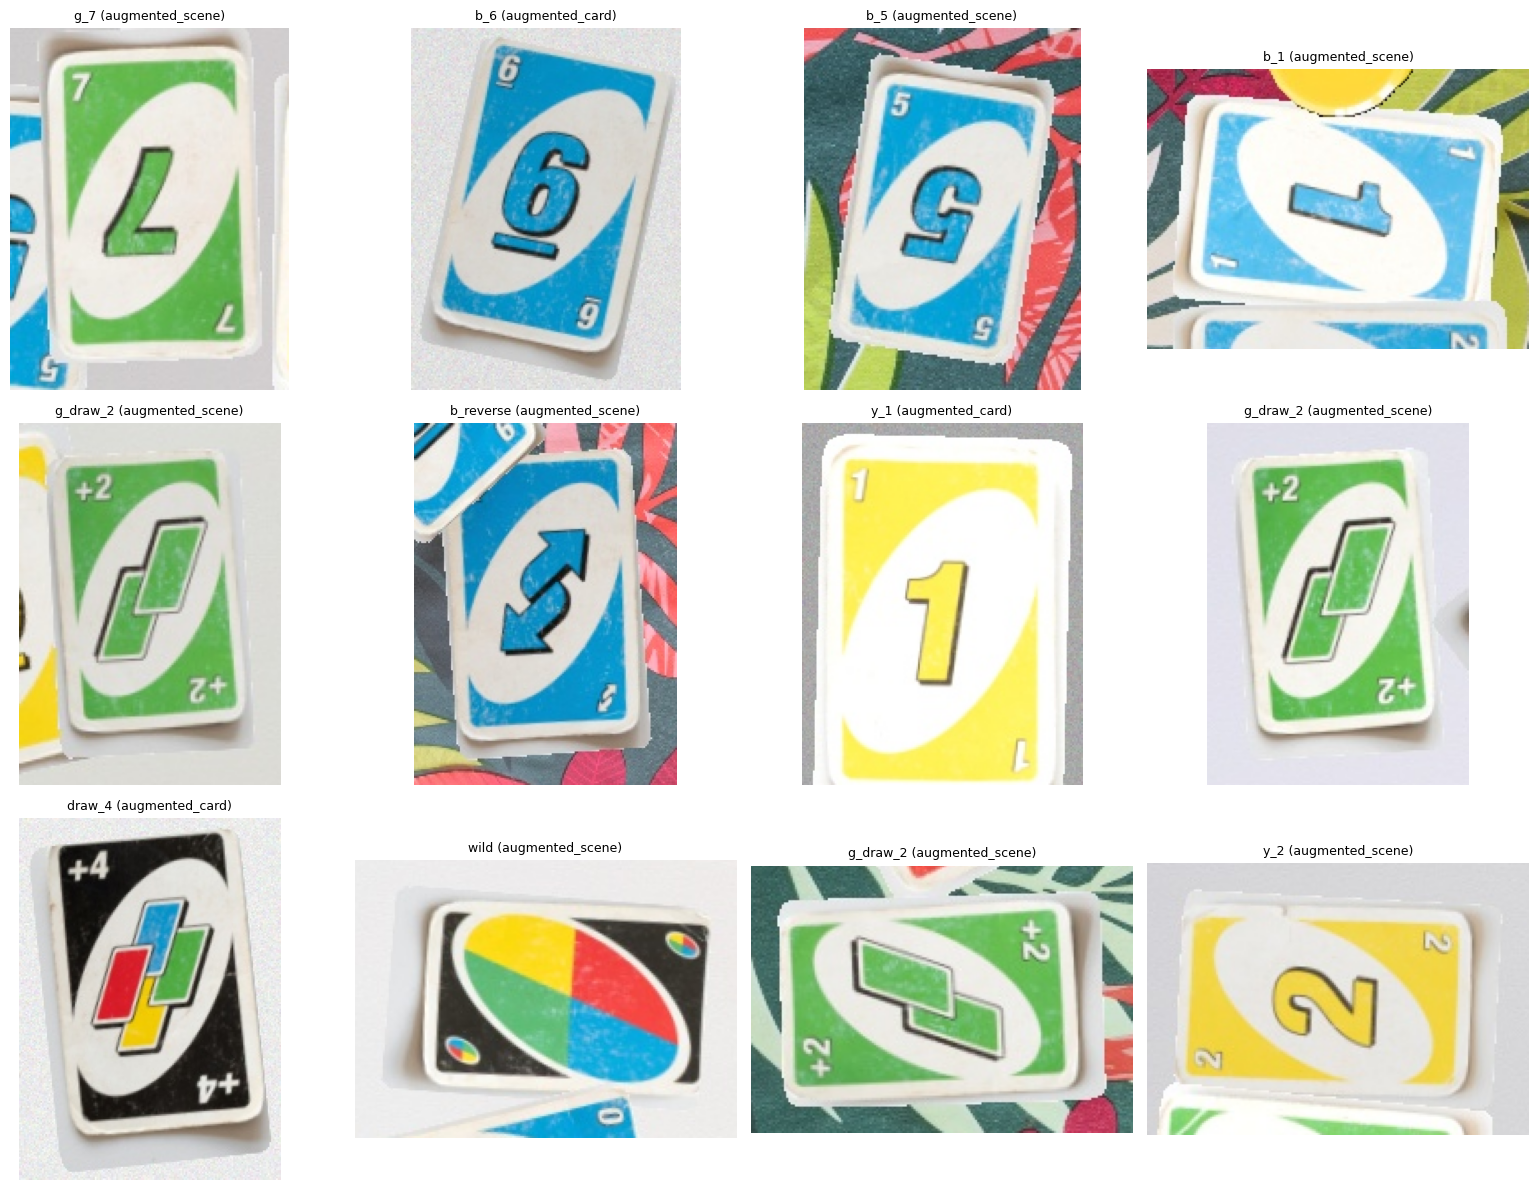

In [4]:
# Quick visual check of the mixed training set.
preview_count = min(12, len(samples))
preview_rng = np.random.default_rng(SEED)
preview_indices = preview_rng.choice(len(samples), size=preview_count, replace=False)

cols = 4
rows = int(np.ceil(preview_count / cols))
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = np.array(axes).reshape(-1)

for ax, sample_index in zip(axes, preview_indices):
    sample = samples[int(sample_index)]
    img_bgr = read_sample_bgr(sample)
    ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
    ax.set_title(f"{sample.label} ({sample.source})", fontsize=9)
    ax.axis("off")

for ax in axes[preview_count:]:
    ax.axis("off")

plt.tight_layout()
plt.show()

## Extract Features And Train

Training still uses ExtraTrees, but now applies source-aware sample weighting and a tiny hyperparameter sweep to keep things simple while improving robustness.

In [5]:
features: list[np.ndarray] = []
labels: list[str] = []
valid_samples: list[CardSample] = []
sample_sources: list[str] = []

print(f"Extracting features from {len(samples)} samples...")
for index, sample in enumerate(samples, start=1):
    img_bgr = read_sample_bgr(sample)
    if img_bgr.size == 0:
        continue
    features.append(extract_features(img_bgr))
    labels.append(sample.label)
    valid_samples.append(sample)
    sample_sources.append(sample.source)
    if index % 500 == 0 or index == len(samples):
        print(f"  {index}/{len(samples)}")

X = np.vstack(features)
labels = np.array(labels)
sample_sources = np.array(sample_sources)

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

print(f"Feature matrix: {X.shape}")
print(f"Classes ({len(label_encoder.classes_)}): {list(label_encoder.classes_)}")

class_counts = Counter(y)
min_class_count = min(class_counts.values())
stratify_y = y if min_class_count >= 2 else None
if stratify_y is None:
    print("[warning] Some classes have only one sample; validation split will not be stratified.")

train_idx, val_idx = train_test_split(
    np.arange(len(y)),
    test_size=0.20,
    random_state=SEED,
    stratify=stratify_y,
 )

per_class_weight = {
    class_id: len(y) / (len(class_counts) * count)
    for class_id, count in class_counts.items()
}
source_weight_values = np.array([SOURCE_WEIGHTS.get(source, 1.0) for source in sample_sources], dtype=np.float32)
class_weight_values = np.array([per_class_weight[int(class_id)] for class_id in y], dtype=np.float32)
sample_weights = source_weight_values * class_weight_values

print(
    f"Sample weight range: {sample_weights.min():.3f} - {sample_weights.max():.3f} "
    f"(mean={sample_weights.mean():.3f})"
 )

candidate_settings = [
    {"n_estimators": 500, "max_features": "sqrt", "min_samples_leaf": 1},
    {"n_estimators": 700, "max_features": "sqrt", "min_samples_leaf": 1},
    {"n_estimators": 900, "max_features": "sqrt", "min_samples_leaf": 2},
    {"n_estimators": 700, "max_features": "log2", "min_samples_leaf": 1},
]

best_val_acc = -1.0
best_bundle = None

for settings in candidate_settings:
    candidate = ExtraTreesClassifier(
        random_state=SEED,
        n_jobs=-1,
        class_weight=None,
        **settings,
    )
    candidate.fit(X[train_idx], y[train_idx], sample_weight=sample_weights[train_idx])
    candidate_val_pred = candidate.predict(X[val_idx])
    candidate_val_acc = accuracy_score(y[val_idx], candidate_val_pred)
    print(f"Candidate {settings} -> val acc {candidate_val_acc * 100:.2f}%")

    if candidate_val_acc > best_val_acc:
        best_val_acc = candidate_val_acc
        best_bundle = (candidate, settings, candidate_val_pred)

if best_bundle is None:
    raise RuntimeError("No candidate model was trained.")

card_clf, best_params, val_pred = best_bundle
train_pred = card_clf.predict(X[train_idx])
train_acc = accuracy_score(y[train_idx], train_pred)
val_acc = accuracy_score(y[val_idx], val_pred)

print(f"Selected settings: {best_params}")
print(f"Train samples: {len(train_idx)} | Val samples: {len(val_idx)}")
print(f"Train accuracy: {train_acc * 100:.1f}%")
print(f"Val accuracy:   {val_acc * 100:.1f}%")

Extracting features from 15264 samples...
  500/15264
  1000/15264
  1500/15264
  2000/15264
  2500/15264
  3000/15264
  3500/15264
  4000/15264
  4500/15264
  5000/15264
  5500/15264
  6000/15264
  6500/15264
  7000/15264
  7500/15264
  8000/15264
  8500/15264
  9000/15264
  9500/15264
  10000/15264
  10500/15264
  11000/15264
  11500/15264
  12000/15264
  12500/15264
  13000/15264
  13500/15264
  14000/15264
  14500/15264
  15000/15264
  15264/15264
Feature matrix: (15264, 2212)
Classes (54): [np.str_('b_0'), np.str_('b_1'), np.str_('b_2'), np.str_('b_3'), np.str_('b_4'), np.str_('b_5'), np.str_('b_6'), np.str_('b_7'), np.str_('b_8'), np.str_('b_9'), np.str_('b_draw_2'), np.str_('b_reverse'), np.str_('b_skip'), np.str_('draw_4'), np.str_('g_0'), np.str_('g_1'), np.str_('g_2'), np.str_('g_3'), np.str_('g_4'), np.str_('g_5'), np.str_('g_6'), np.str_('g_7'), np.str_('g_8'), np.str_('g_9'), np.str_('g_draw_2'), np.str_('g_reverse'), np.str_('g_skip'), np.str_('r_0'), np.str_('r_1'), np.s

In [6]:
# Save the DO classifier and the small bit of metadata needed by test_classifier_do.ipynb.
joblib.dump(card_clf, CARD_CLF_PATH)
np.save(CARD_CLASSES_PATH, label_encoder.classes_)

config = {
    "model_file": CARD_CLF_PATH.name,
    "classes_file": CARD_CLASSES_PATH.name,
    "image_size": IMG_SIZE,
    "fourier_coeffs": FOURIER_COEFFS,
    "center_crop_fraction": CENTER_CROP_FRACTION,
    "feature_order": ["hsv_histogram", "hog_global", "fourier_global", "hog_center", "fourier_center"],
    "classifier": "ExtraTreesClassifier",
    "selected_params": best_params,
    "source_weights": SOURCE_WEIGHTS,
    "n_samples": int(len(valid_samples)),
    "source_counts": dict(source_counts),
    "validation_accuracy": float(val_acc),
    "seed": SEED,
}
with CARD_CONFIG_PATH.open("w", encoding="utf-8") as config_file:
    json.dump(config, config_file, indent=2)

print(f"Saved classifier: {CARD_CLF_PATH}")
print(f"Saved classes:    {CARD_CLASSES_PATH}")
print(f"Saved config:     {CARD_CONFIG_PATH}")

Saved classifier: C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\card_clf_do.pkl
Saved classes:    C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\card_classes_do.npy
Saved config:     C:\Users\doria\Documents\EPFL\IA\iapr2026do\project\models\card_classifier_do_config.json


## Validation Diagnostics

              precision    recall  f1-score   support

         b_0       0.93      0.98      0.95        54
         b_1       0.91      0.94      0.92        52
         b_2       0.94      0.91      0.93        56
         b_3       0.98      0.93      0.95        56
         b_4       0.88      0.91      0.90        57
         b_5       0.95      0.91      0.93        57
         b_6       0.93      0.97      0.95        58
         b_7       0.88      0.91      0.89        56
         b_8       0.93      0.96      0.95        56
         b_9       0.98      0.93      0.96        59
    b_draw_2       0.86      0.97      0.91        58
   b_reverse       0.96      0.90      0.93        60
      b_skip       0.98      0.92      0.95        60
      draw_4       0.93      0.93      0.93        67
         g_0       0.85      0.98      0.91        56
         g_1       0.85      0.89      0.87        53
         g_2       0.98      0.95      0.96        58
         g_3       0.98    

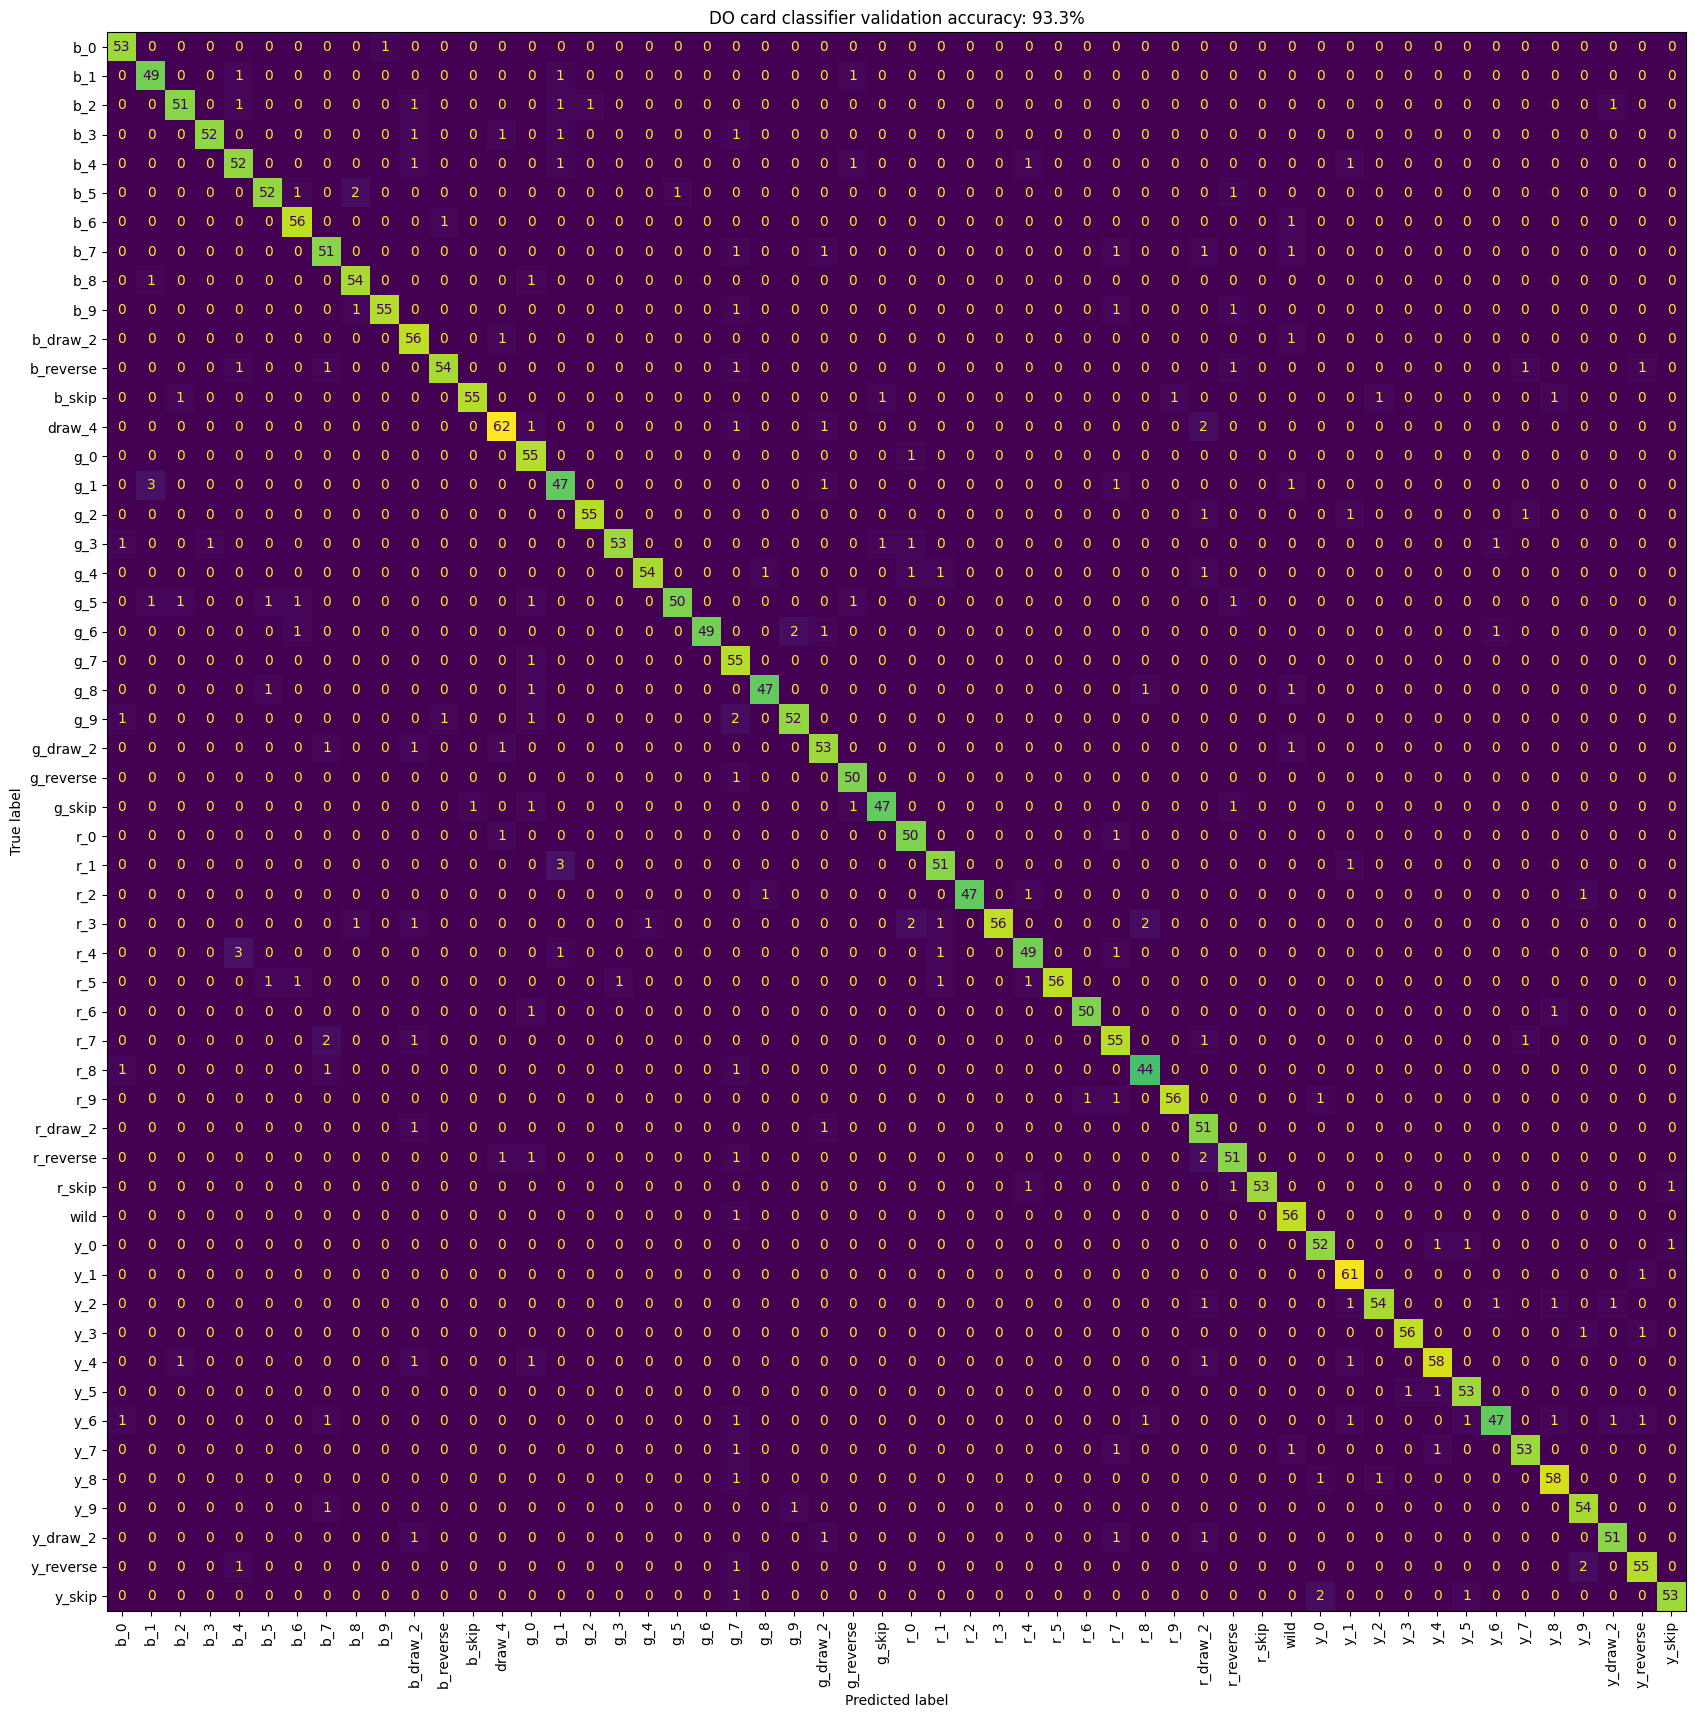

In [7]:
true_labels = label_encoder.inverse_transform(y[val_idx])
pred_labels = label_encoder.inverse_transform(val_pred)

print(classification_report(true_labels, pred_labels, zero_division=0))

fig_size = max(8, 0.32 * len(label_encoder.classes_))
fig, ax = plt.subplots(figsize=(fig_size, fig_size))
ConfusionMatrixDisplay.from_predictions(
    true_labels,
    pred_labels,
    labels=label_encoder.classes_,
    xticks_rotation=90,
    colorbar=False,
    ax=ax,
)
ax.set_title(f"DO card classifier validation accuracy: {val_acc * 100:.1f}%")
plt.tight_layout()
plt.show()

Wrong validation predictions: 204 / 3053


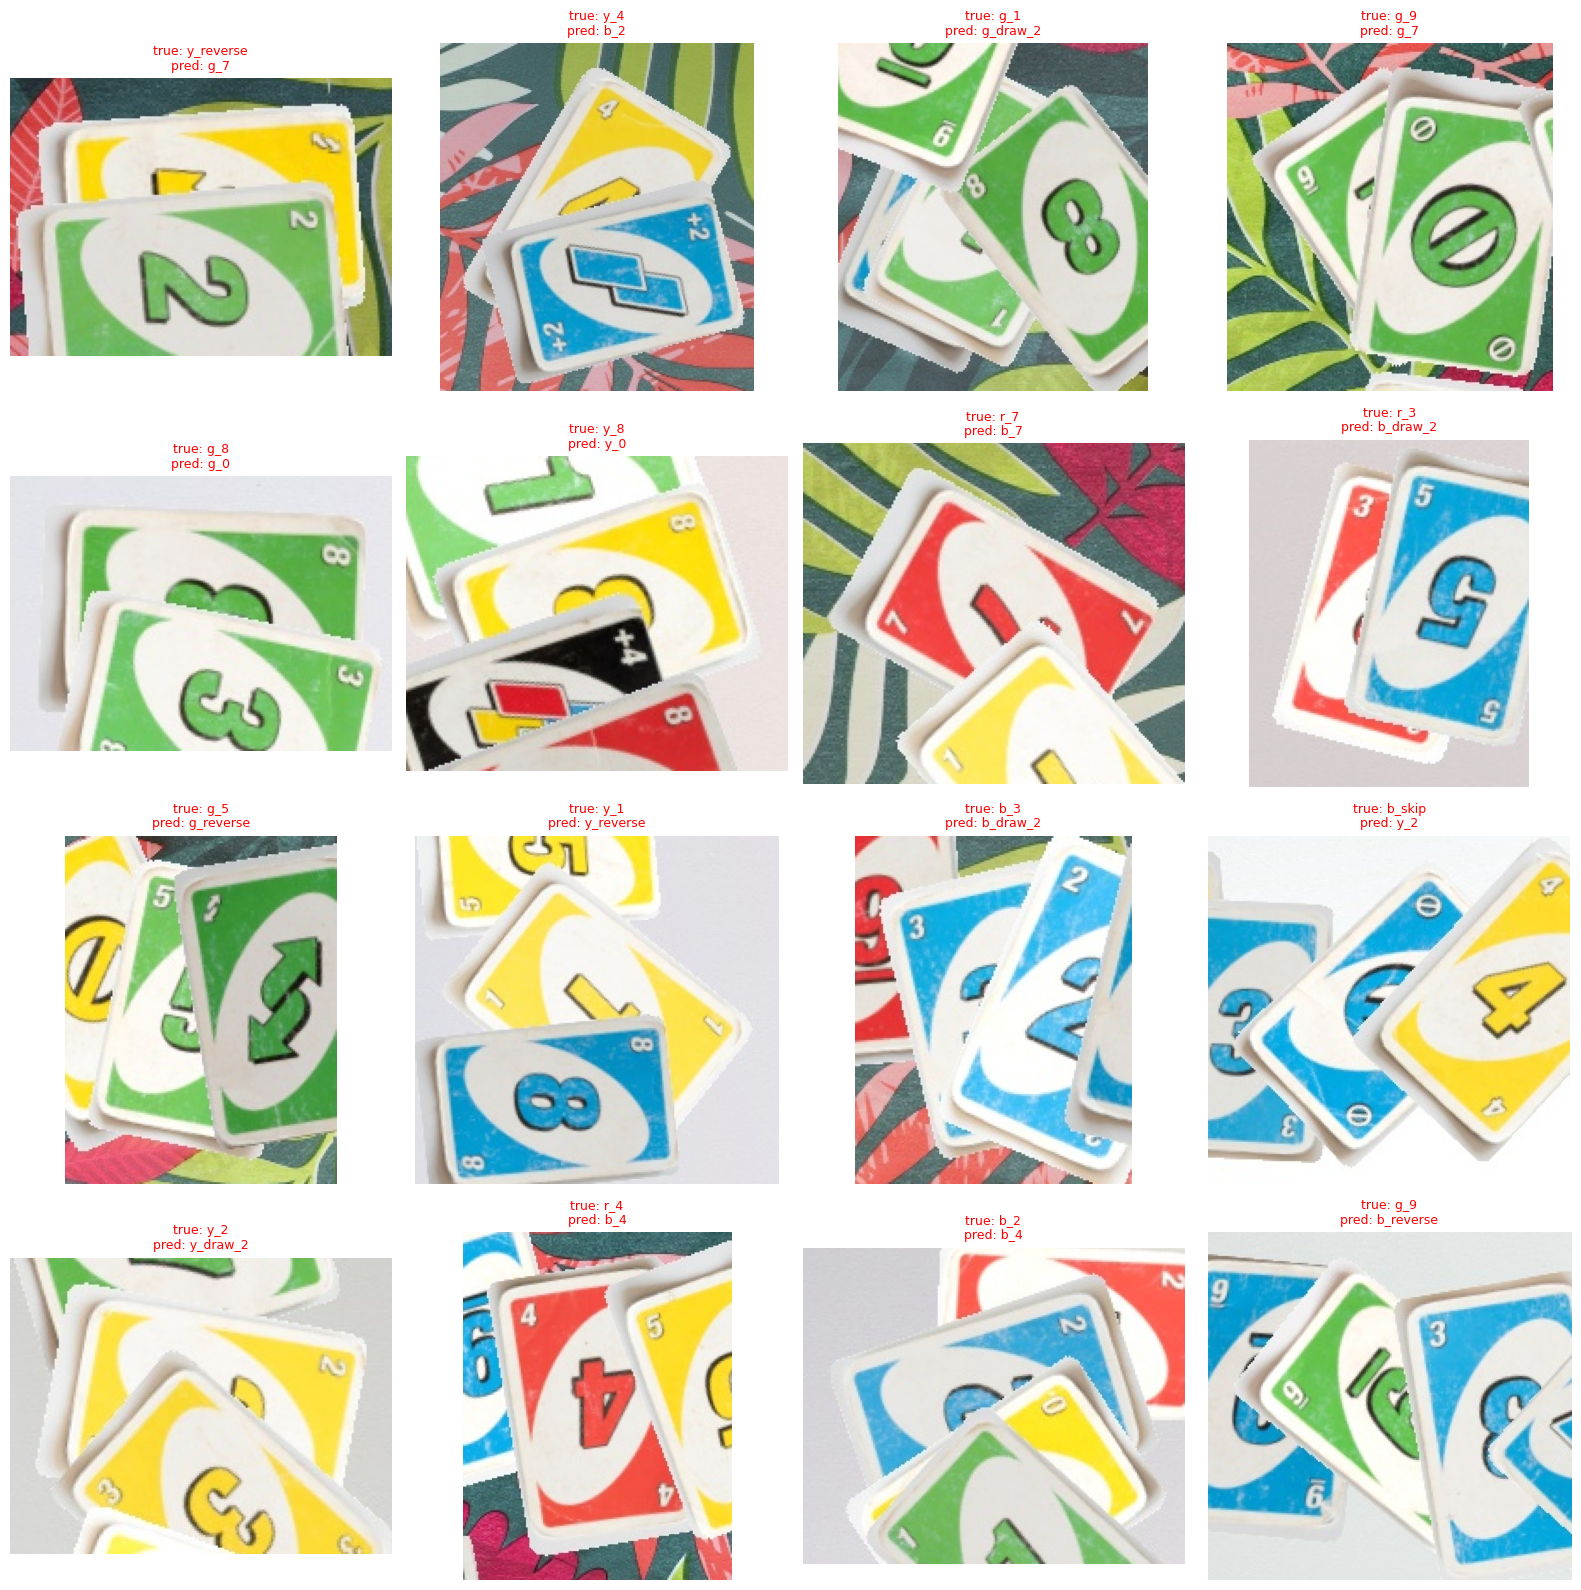

In [8]:
wrong = [
    (sample_index, true_label, pred_label)
    for sample_index, true_label, pred_label in zip(val_idx, true_labels, pred_labels)
    if true_label != pred_label
]

print(f"Wrong validation predictions: {len(wrong)} / {len(val_idx)}")

if wrong:
    show_count = min(16, len(wrong))
    cols = 4
    rows = int(np.ceil(show_count / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (sample_index, true_label, pred_label) in zip(axes, wrong[:show_count]):
        sample = valid_samples[int(sample_index)]
        img_bgr = read_sample_bgr(sample)
        ax.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
        ax.set_title(f"true: {true_label}\npred: {pred_label}", color="red", fontsize=9)
        ax.axis("off")

    for ax in axes[show_count:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()